In [10]:
import numpy as np
import random
import seaborn as sns
from tqdm import tqdm

In [11]:
MIN_X = -32
MAX_X = 32

DIM = 30

NUM_POPULATION = 500
NUM_GENERATIONS = 120

TX_CROSSOVER = 0.80
TX_MUTATION = 0.20
MUTATION_FACTOR = 0.50

In [12]:
def f(x: np.ndarray) -> float:
    assert x.shape == (DIM,)
    
    f_x = -20 * np.exp(-0.2 * np.sqrt(np.sum(x ** 2) / DIM)) - np.exp(np.sum(np.cos(2 * np.pi * x)) / DIM) + 20 + np.e
    if np.any(x < MIN_X) or np.any(x > MAX_X):
        return f_x + 2 * abs(f_x)
    
    return f_x

In [13]:
def selection(pop: np.array, f_pop: np.array) -> np.array:
    assert pop.shape == (NUM_POPULATION, DIM)
    assert f_pop.shape == (NUM_POPULATION,)

    new_pop = []
    while len(new_pop) < NUM_POPULATION:
        i1, i2 = np.random.choice(NUM_POPULATION, 2)

        if f_pop[i1] <= f_pop[i2]:
            new_pop.append(pop[i1])
        else:
            new_pop.append(pop[i2])

    new_pop = np.array(new_pop)
    assert new_pop.shape == (NUM_POPULATION, DIM)
    return new_pop

In [14]:
def crossover(pop: np.array) -> np.array:
    assert pop.shape == (NUM_POPULATION, DIM)

    new_pop = []
    while len(new_pop) < NUM_POPULATION:
        i1, i2 = np.random.choice(NUM_POPULATION, 2)
        p1, p2 = pop[i1], pop[i2]

        if random.random() > TX_CROSSOVER:
            new_pop.append(p1)
            new_pop.append(p2)
        else:
            m1 = np.random.rand(DIM) < 0.5
            m2 = np.random.rand(DIM) < 0.5
            c1 = np.where(m1, p1, p2)
            c2 = np.where(m2, p1, p2)
            new_pop.append(c1)
            new_pop.append(c2)
    
    new_pop = np.array(new_pop)
    assert new_pop.shape == (NUM_POPULATION, DIM)
    return new_pop

In [15]:
def mutation(pop: np.array, base: np.array = None) -> np.array:
    assert pop.shape == (NUM_POPULATION, DIM)

    new_pop = []
    for i in pop:
        if random.random() > TX_MUTATION:
            new_pop.append(i)
        else:
            i1, i2 = np.random.choice(NUM_POPULATION, 2)
            aux = base if base is not None else i
            new_i = aux + MUTATION_FACTOR * (pop[i1] - pop[i2])
            new_pop.append(new_i)
            
    new_pop = np.array(new_pop)
    assert new_pop.shape == (NUM_POPULATION, DIM)
    return new_pop

In [16]:
pop = np.random.uniform(MIN_X, MAX_X + 1, (NUM_POPULATION, DIM))

best = None
best_f = None

best_history = []

with tqdm(iterable=range(NUM_GENERATIONS), desc="Generation") as pbar:
    for gen in pbar:
        f_pop = np.apply_along_axis(func1d=f, arr=pop, axis=1)

        min_i = np.argmin(f_pop)
        curr_best = pop[min_i]
        curr_best_f = f_pop[min_i]

        if best_f is None or curr_best_f < best_f:
            best = curr_best
            best_f = curr_best_f

        best_history.append(best_f)

        # tqdm info
        pbar.set_postfix({
            'iter': gen + 1,
            'f_score': f'{best_f:.3f}'
        })

        new_pop = selection(pop, f_pop)
        new_pop = crossover(new_pop)
        new_pop = mutation(new_pop, base=curr_best)

        pop = new_pop
    

Generation: 100%|██████████| 120/120 [00:01<00:00, 83.56it/s, iter=120, f_score=0.002]


In [17]:
print(round(best_f, 2))

0.0


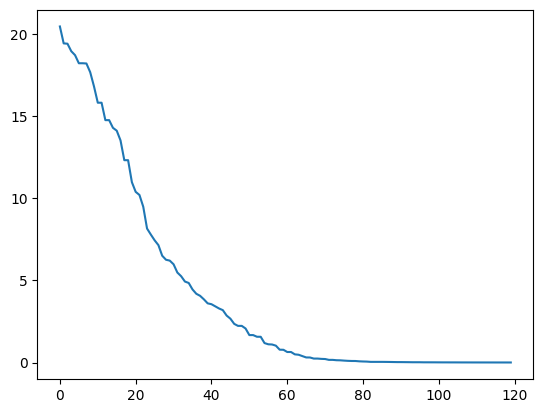

In [18]:
sns.lineplot(x=range(len(best_history)), y=best_history);